In [1]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00


In [2]:
!pip install -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.7 MB/s eta 0:00:00


In [3]:
import ee

In [4]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
              opt_url='https://earthengine-highvolume.googleapis.com')

In [5]:
import geemap

In [6]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [28]:
roi = ee.Geometry.Point(map.draw_last_feature.geometry().coordinates().getInfo())
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Point",
    "arguments": {
      "coordinates": {
        "constantValue": [
          30.344192,
          7.667101
        ]
      }
    }
  }
})

In [29]:
border = (ee.FeatureCollection("FAO/GAUL/2015/level0")

  .filterBounds(roi)
  .geometry()
  .simplify(100)
)
vis_params = {"color":"yellow"}
map.addLayer(border, vis_params, "border")

In [30]:
pop = ee.ImageCollection("JRC/GHSL/P2023A/GHS_POP")
pop

In [31]:
pop_stack = pop.toBands().clip(roi)
pop_stack

In [32]:
import geemap

map = geemap.Map()
map.add("basemap_selector")
map.addLayer(pop_stack,{},'pop_stack')

In [44]:
def pop_count(img):
  pop_sum = img.reduceRegion(reducer = ee.Reducer.sum(), geometry = border, scale = 100, bestEffort=True, maxPixels=1e9).values().get(0)
  date = img.date().format('YYYY-MM-dd')
  return ee.Feature(None, {'date': date, 'pop': pop_sum})

In [47]:
pop_val = pop.map(pop_count)
feature_list = pop_val.aggregate_array('pop').getInfo()
date_list = pop_val.aggregate_array('date').getInfo()
pop_val

In [36]:
import numpy as np
import pandas as pd

In [48]:
pop_sum = feature_list
pop_sum

[3713652.4424858624,
 4188555.9591467194,
 4704338.398303225,
 4749810.1417872785,
 5302699.992799261,
 6116593.049758155,
 7666695.872037026,
 9720307.69230635,
 11202298.59979941,
 10620440.962289494,
 11488516.779985288,
 12590248.86288081]

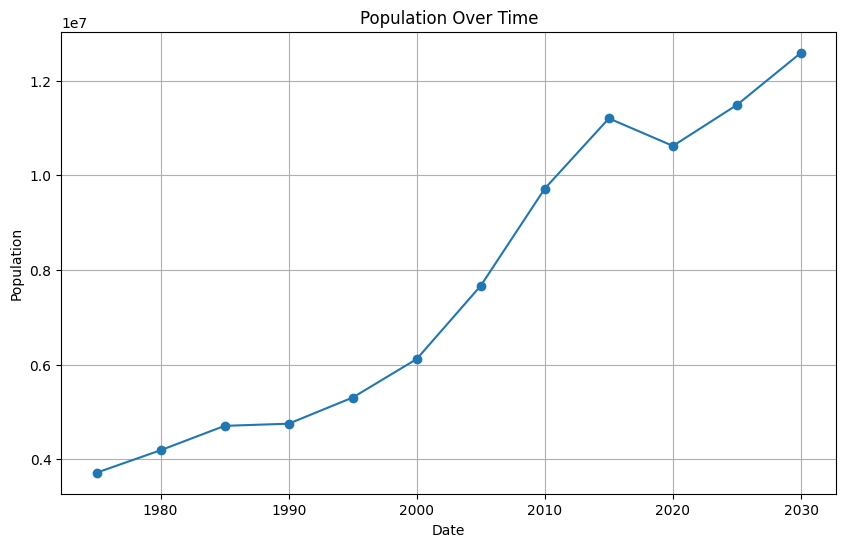

In [49]:
import matplotlib.pyplot as plt

# Create a DataFrame
df = pd.DataFrame({'Date': date_list, 'Population': pop_sum})

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Plot the population over time
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Population'], marker='o')
plt.title('Population Over Time')
plt.xlabel('Date')
plt.ylabel('Population')
plt.grid(True)
plt.show()

In [51]:
# Set 'Date' as the index for calculations
df_index = df.set_index('Date')

# Calculate the population growth rate (percentage change)
df_index['growth_rate'] = df_index['Population'].pct_change() * 100

# Smooth the growth rate using a rolling mean (e.g., a 2-period window)
growth_rate_smoothed = df_index['growth_rate'].rolling(window=2, min_periods=1).mean()

# Display the DataFrame with growth rates
display(df_index)

,Population,growth_rate
Date,,
1975-01-01,3.713652e+06,NaN
1980-01-01,4.188556e+06,12.788044
1985-01-01,4.704338e+06,12.314087
1990-01-01,4.749810e+06,0.966592
1995-01-01,5.302700e+06,11.640252
2000-01-01,6.116593e+06,15.348654
2005-01-01,7.666696e+06,25.342585
2010-01-01,9.720308e+06,26.786139
2015-01-01,1.120230e+07,15.246337


In [ ]:
# Plotting Growth Rate (Original vs. Smoothed)

plt.figure(figsize=(10, 6))
df_index['growth_rate'].plot(label='Original Growth Rate', legend=True)
growth_rate_smoothed.plot(label='Smoothed Growth Rate', legend=True)
plt.title('South Sudan Population Change 1980-2030')
plt.xlabel('Date')
plt.ylabel('South Sudan Population Change 1980-2030')
plt.grid(True)
plt.show()

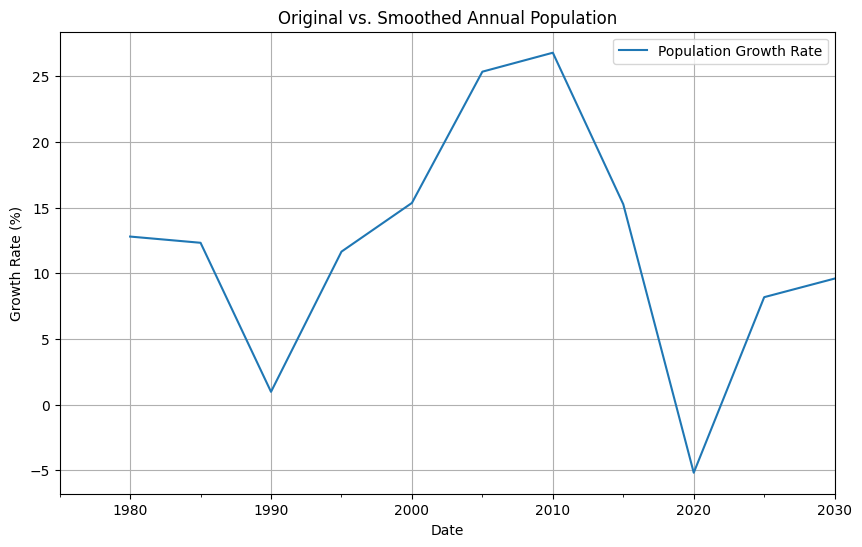

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_index['growth_rate'].plot(label='Population Growth Rate', legend=True)
plt.title('Original vs. Smoothed Annual Population')
plt.xlabel('Date')
plt.ylabel('Growth Rate (%)')
plt.grid(True)
plt.show()

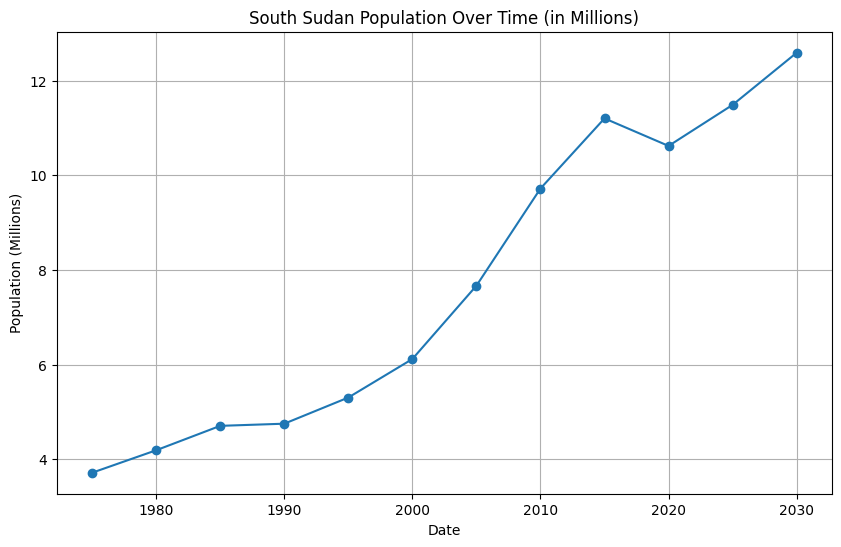

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Population'] / 1_000_000, marker='o')
plt.title('South Sudan Population Over Time (in Millions)')
plt.xlabel('Date')
plt.ylabel('Population (Millions)')
plt.grid(True)
plt.show()

In [64]:
plt.savefig("ssd_population.png", dpi = 365, bbox_inches = 'tight')

<Figure size 640x480 with 0 Axes>

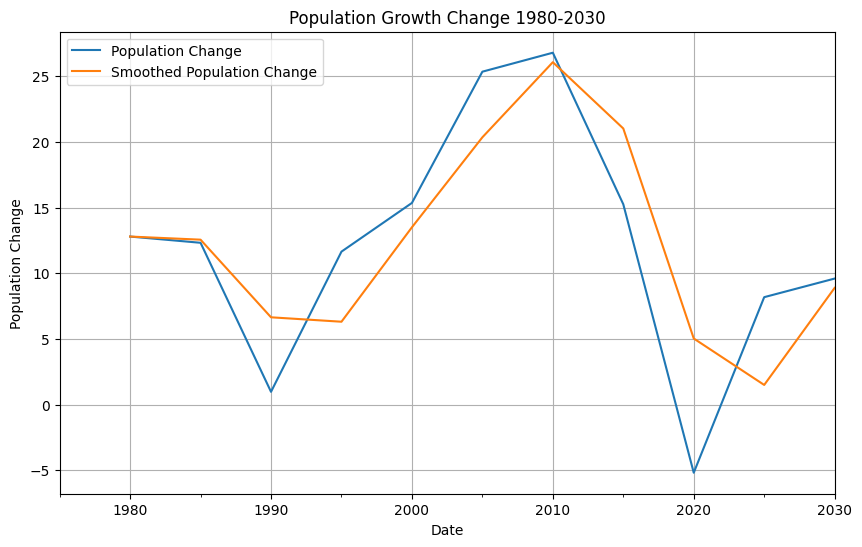

In [74]:
plt.figure(figsize=(10, 6))
df_index['growth_rate'].plot(label='Population Change', legend=True)
growth_rate_smoothed.plot(label='Smoothed Population Change', legend=True)
plt.title('Population Growth Change 1980-2030')
plt.xlabel('Date')
plt.ylabel('Population Change')
plt.grid(True)
plt.show()